# Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pyglam import GlamFKML
import seaborn as sns

# Carregar os modelos

In [2]:
try:
    mlp_l1 = joblib.load("model_mlp_lambda1.pkl")
    mlp_l2 = joblib.load("model_mlp_lambda2.pkl")
    scaler = joblib.load("scaler.pkl")
    print("Modelos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivos .pkl não encontrados. Rode o treinamento primeiro.")
except Exception as e:
    print(f"Erro ao carregar modelos: {e}")

Modelos carregados com sucesso!


# Definir condições fixas e gerar dados para predição

In [3]:
# Definir as condições fixas para a predição
fck_input = 30.0
rh_input = 65.0
cover_input = 25.0

# time list
#lista_tempos = [0.0, 16.666666666666668, 33.333333333333336, 50.0, 66.66666666666667, 83.33333333333334, 100.0, 116.66666666666667, 133.33333333333334, 150.0]
lista_tempos = list(range(0, 151, 10))

# Cria um DataFrame repetindo as condições fixas para cada tempo da lista
novos_dados = pd.DataFrame({
    "fck_mpa": [fck_input] * len(lista_tempos),
    "rh_percent": [rh_input] * len(lista_tempos),
    "cover_mm": [cover_input] * len(lista_tempos),
    "tempo": lista_tempos
})

print(f"\nRealizando predições para Fck={fck_input}MPa, RH={rh_input}%, Cobrimento={cover_input}mm...\n")


Realizando predições para Fck=30.0MPa, RH=65.0%, Cobrimento=25.0mm...



# Fazer predições

In [4]:
import time

# Escalonar os novos dados e fazer as predições
X_novos_escalonados = scaler.transform(novos_dados)

# Lista para armazenar os tempos de processamento
tempos_processamento = []

# Fazemos as predições separadas e medimos o tempo
for i in range(len(novos_dados)):
    start_time = time.time()
    X_sample = X_novos_escalonados[i].reshape(1, -1)
    
    pred_l1 = mlp_l1.predict(X_sample)[0]
    pred_l2 = mlp_l2.predict(X_sample)[0]
    
    end_time = time.time()
    tempo_processamento = end_time - start_time
    tempos_processamento.append(tempo_processamento)

# Adiciona as predições ao DataFrame
novos_dados["pred_lambda_1"] = [mlp_l1.predict(X_novos_escalonados[i].reshape(1, -1))[0] 
                                 for i in range(len(novos_dados))]
novos_dados["pred_lambda_2"] = [mlp_l2.predict(X_novos_escalonados[i].reshape(1, -1))[0] 
                                 for i in range(len(novos_dados))]

# Adicionar coluna com o tempo que demorou para gerar as predições de cada tempo
novos_dados["tempo_processamento_s"] = tempos_processamento

# O dataframe agora devolve a relação completa do tempo vs lambdas
print(novos_dados.to_string(index=False))

d:\Documentos\ic_victor\myenv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


 fck_mpa  rh_percent  cover_mm  tempo  pred_lambda_1  pred_lambda_2  tempo_processamento_s
    30.0        65.0      25.0      0      24.634955       2.886726               0.040406
    30.0        65.0      25.0     10      16.290253       2.325313               0.000000
    30.0        65.0      25.0     20      11.304898       2.122123               0.000000
    30.0        65.0      25.0     30       8.333396       1.917834               0.000000
    30.0        65.0      25.0     40       5.499568       1.739021               0.000000
    30.0        65.0      25.0     50       3.254840       1.605076               0.000000
    30.0        65.0      25.0     60       1.130864       1.490282               0.000000
    30.0        65.0      25.0     70      -0.844026       1.398975               0.000000
    30.0        65.0      25.0     80      -2.411618       1.316883               0.000000
    30.0        65.0      25.0     90      -4.022549       1.240116               0.000000

# Adicionar lambdas 3 e 4

In [5]:
novos_dados["pred_lambda_3"] = 0.13  # lambda3 fixo
novos_dados["pred_lambda_4"] = 0.14  # lambda4 fixo

print("\nDataFrame com todos os lambdas:")
print(novos_dados[["tempo", "pred_lambda_1", "pred_lambda_2", "pred_lambda_3", "pred_lambda_4"]].to_string(index=False))


DataFrame com todos os lambdas:
 tempo  pred_lambda_1  pred_lambda_2  pred_lambda_3  pred_lambda_4
     0      24.634955       2.886726           0.13           0.14
    10      16.290253       2.325313           0.13           0.14
    20      11.304898       2.122123           0.13           0.14
    30       8.333396       1.917834           0.13           0.14
    40       5.499568       1.739021           0.13           0.14
    50       3.254840       1.605076           0.13           0.14
    60       1.130864       1.490282           0.13           0.14
    70      -0.844026       1.398975           0.13           0.14
    80      -2.411618       1.316883           0.13           0.14
    90      -4.022549       1.240116           0.13           0.14
   100      -5.570340       1.171745           0.13           0.14
   110      -6.975416       1.118230           0.13           0.14
   120      -8.661474       1.067844           0.13           0.14
   130     -10.149804       1

# Gerar amostras GLAM para cada tempo

In [6]:
# Inicializar lista para armazenar as amostras
amostras_por_tempo = []
n_amostras = 10000

print("\nGerando amostras GLAM para cada tempo...")

for idx, row in novos_dados.iterrows():
    # Extrair os lambdas para este tempo
    lam1 = row["pred_lambda_1"]
    lam2 = row["pred_lambda_2"]
    lam3 = row["pred_lambda_3"]  # 0.13
    lam4 = row["pred_lambda_4"]  # 0.14
    
    # Criar objeto GLAM com os parâmetros específicos
    g = GlamFKML(lam1=lam1, lam2=lam2, lam3=lam3, lam4=lam4)
    
    # Gerar amostras
    rvs_glam = g.rvs(size=n_amostras)
    amostras_por_tempo.append(rvs_glam)
    
    # Mostrar estatísticas básicas
    tempo_atual = row["tempo"]
    print(f"Tempo {tempo_atual:.1f}: μ={lam1:.4f}, σ={lam2:.4f}, " +
          f"média amostral={np.mean(rvs_glam):.4f}, desvio={np.std(rvs_glam):.4f}")

print(f"\nGeradas {n_amostras} amostras para cada um dos {len(lista_tempos)} tempos.")


Gerando amostras GLAM para cada tempo...
Tempo 0.0: μ=24.6350, σ=2.8867, média amostral=24.6323, desvio=0.5021
Tempo 10.0: μ=16.2903, σ=2.3253, média amostral=16.2870, desvio=0.6233
Tempo 20.0: μ=11.3049, σ=2.1221, média amostral=11.3013, desvio=0.6830
Tempo 30.0: μ=8.3334, σ=1.9178, média amostral=8.3294, desvio=0.7557
Tempo 40.0: μ=5.4996, σ=1.7390, média amostral=5.4952, desvio=0.8334
Tempo 50.0: μ=3.2548, σ=1.6051, média amostral=3.2501, desvio=0.9030
Tempo 60.0: μ=1.1309, σ=1.4903, média amostral=1.1257, desvio=0.9725
Tempo 70.0: μ=-0.8440, σ=1.3990, média amostral=-0.8495, desvio=1.0360
Tempo 80.0: μ=-2.4116, σ=1.3169, média amostral=-2.4174, desvio=1.1006
Tempo 90.0: μ=-4.0225, σ=1.2401, média amostral=-4.0287, desvio=1.1687
Tempo 100.0: μ=-5.5703, σ=1.1717, média amostral=-5.5768, desvio=1.2369
Tempo 110.0: μ=-6.9754, σ=1.1182, média amostral=-6.9822, desvio=1.2961
Tempo 120.0: μ=-8.6615, σ=1.0678, média amostral=-8.6686, desvio=1.3573
Tempo 130.0: μ=-10.1498, σ=1.0301, média 

# Gráfico tipo "spaghetti"

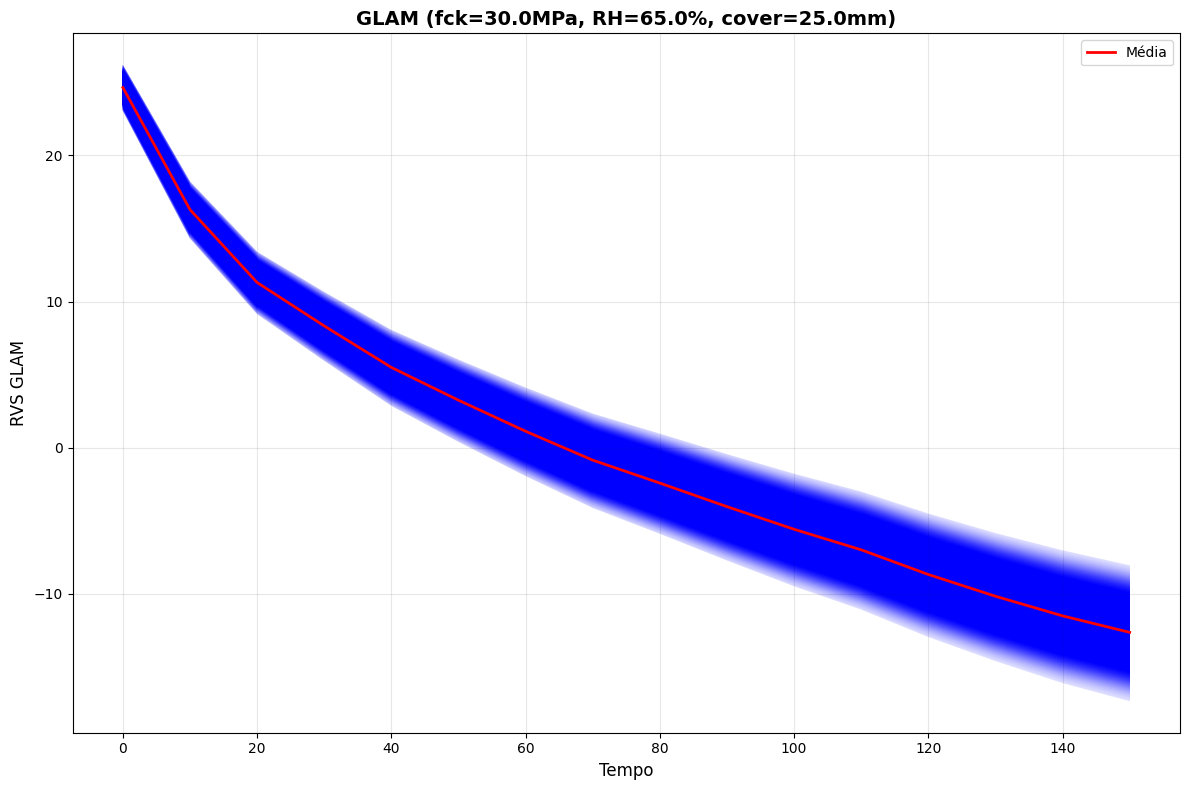

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plotar cada amostra como uma linha
for i in range(n_amostras):
    # Extrair a i-ésima amostra para cada tempo
    amostras_linha = [amostras_por_tempo[t][i] for t in range(len(lista_tempos))]
    ax.plot(lista_tempos, amostras_linha, alpha=0.1, color='blue', linewidth=0.5)

# Adicionar a média
medias = [np.mean(amostras_por_tempo[t]) for t in range(len(lista_tempos))]
ax.plot(lista_tempos, medias, color='red', linewidth=2, label='Média')

# Configurar o gráfico
ax.set_xlabel('Tempo', fontsize=12)
ax.set_ylabel('RVS GLAM', fontsize=12)
ax.set_title(f'GLAM (fck={fck_input}MPa, RH={rh_input}%, cover={cover_input}mm)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo do RUL (Remaining Useful Life)

In [9]:
threshold = 0
tempos_falha = []

for i in range(1000):
    amostras_individuais = [amostras_por_tempo[t][i] for t in range(len(lista_tempos))]
    
    for t in range(1, len(lista_tempos)):
        if amostras_individuais[t] <= threshold and amostras_individuais[t-1] > threshold:
            # Interpolação linear
            t_anterior = lista_tempos[t-1]
            t_atual = lista_tempos[t]
            val_anterior = amostras_individuais[t-1]
            val_atual = amostras_individuais[t]
            
            fracao = (threshold - val_anterior) / (val_atual - val_anterior)
            tempo_falha = t_anterior + fracao * (t_atual - t_anterior)
            tempos_falha.append(tempo_falha)
            break

tempos_falha = np.array(tempos_falha)

# Estatísticas
print(f"Tempo médio de falha: {np.mean(tempos_falha):.2f}")
print(f"Tempo mediano de falha: {np.median(tempos_falha):.2f}")
print(f"Desvio padrão: {np.std(tempos_falha):.2f}")
print(f"Percentil 5%: {np.percentile(tempos_falha, 5):.2f}")
print(f"Percentil 95%: {np.percentile(tempos_falha, 95):.2f}")

Tempo médio de falha: 57.39
Tempo mediano de falha: 57.81
Desvio padrão: 1.65
Percentil 5%: 54.04
Percentil 95%: 59.28


# PDF do RUL

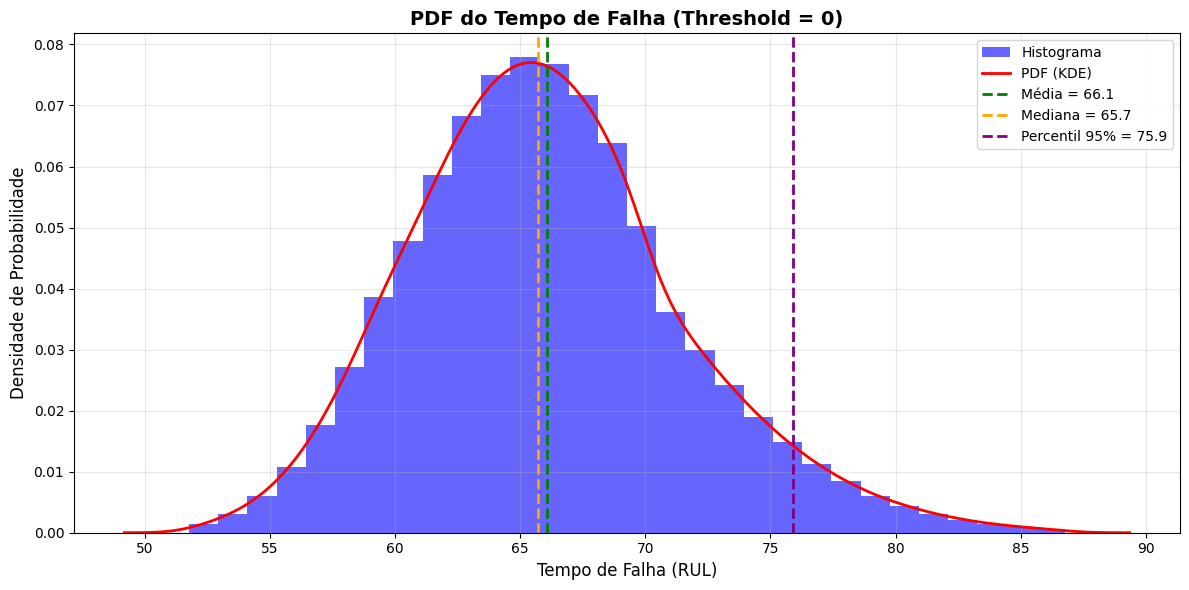


Estatísticas do tempo de falha (RUL):
Média: 66.06
Mediana: 65.72
Desvio padrão: 5.43
Percentil 95%: 75.88
Min: 51.77
Max: 86.77


In [10]:
# Encontrar quando as amostras cruzam o zero
# Definir o limite de falha (threshold)
threshold = 0  # ou outro valor apropriado

# Encontrar o tempo de falha para cada amostra
tempos_falha = []

for i in range(n_amostras):
    amostras_individuais = [amostras_por_tempo[t][i] for t in range(len(lista_tempos))]
    
    # Encontrar o primeiro tempo onde a amostra cruza o threshold
    tempo_falha = None
    for t in range(1, len(lista_tempos)):
        if amostras_individuais[t] <= threshold and amostras_individuais[t-1] > threshold:
            # Interpolação linear para encontrar o ponto exato
            t_anterior = lista_tempos[t-1]
            t_atual = lista_tempos[t]
            val_anterior = amostras_individuais[t-1]
            val_atual = amostras_individuais[t]
            
            # Interpolação
            fracao = (threshold - val_anterior) / (val_atual - val_anterior)
            tempo_falha = t_anterior + fracao * (t_atual - t_anterior)
            break
    
    if tempo_falha is not None:
        tempos_falha.append(tempo_falha)
    else:
        # Se nunca cruzar, considerar o último tempo
        tempos_falha.append(lista_tempos[-1])

# Converter para array numpy
tempos_falha = np.array(tempos_falha)

# Plotar PDF do tempo de falha
fig, ax = plt.subplots(figsize=(12, 6))

# Histograma e KDE do tempo de falha
ax.hist(tempos_falha, bins=30, density=True, alpha=0.6, color='blue', label='Histograma')
sns.kdeplot(tempos_falha, ax=ax, color='red', linewidth=2, label='PDF (KDE)')

# Adicionar estatísticas
media_falha = np.mean(tempos_falha)
mediana_falha = np.median(tempos_falha)
percentil_95 = np.percentile(tempos_falha, 95)

ax.axvline(media_falha, color='green', linestyle='--', linewidth=2, label=f'Média = {media_falha:.1f}')
ax.axvline(mediana_falha, color='orange', linestyle='--', linewidth=2, label=f'Mediana = {mediana_falha:.1f}')
ax.axvline(percentil_95, color='purple', linestyle='--', linewidth=2, label=f'Percentil 95% = {percentil_95:.1f}')

ax.set_xlabel('Tempo de Falha (RUL)', fontsize=12)
ax.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax.set_title(f'PDF do Tempo de Falha (Threshold = {threshold})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstatísticas do tempo de falha (RUL):")
print(f"Média: {media_falha:.2f}")
print(f"Mediana: {mediana_falha:.2f}")
print(f"Desvio padrão: {np.std(tempos_falha):.2f}")
print(f"Percentil 95%: {percentil_95:.2f}")
print(f"Min: {np.min(tempos_falha):.2f}")
print(f"Max: {np.max(tempos_falha):.2f}")

# PDFs para diferentes tempos

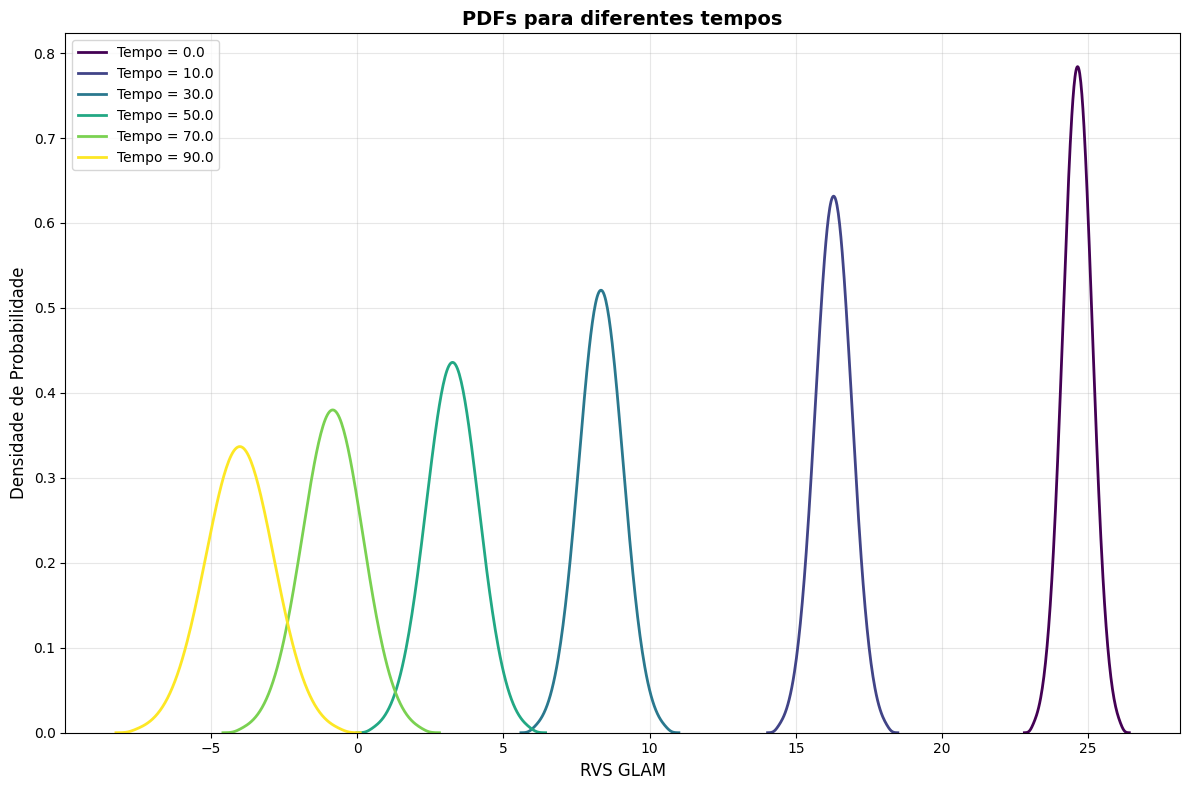

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# Selecionar alguns tempos para visualizar
tempos_para_plotar = [0, 1, 3, 5, 7, 9]  # índices dos tempos
cores = plt.cm.viridis(np.linspace(0, 1, len(tempos_para_plotar)))

for idx_tempo, cor in zip(tempos_para_plotar, cores):
    tempo_real = lista_tempos[idx_tempo]
    amostras = amostras_por_tempo[idx_tempo]
    
    # Plotar histograma (PDF empírica)
    sns.kdeplot(amostras, ax=ax, color=cor, 
                label=f'Tempo = {tempo_real:.1f}', linewidth=2)

ax.set_xlabel('RVS GLAM', fontsize=12)
ax.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax.set_title(f'PDFs para diferentes tempos', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# PDF dado um tempo específico (RUL condicional)


Analisando RUL condicional para t = 50.0


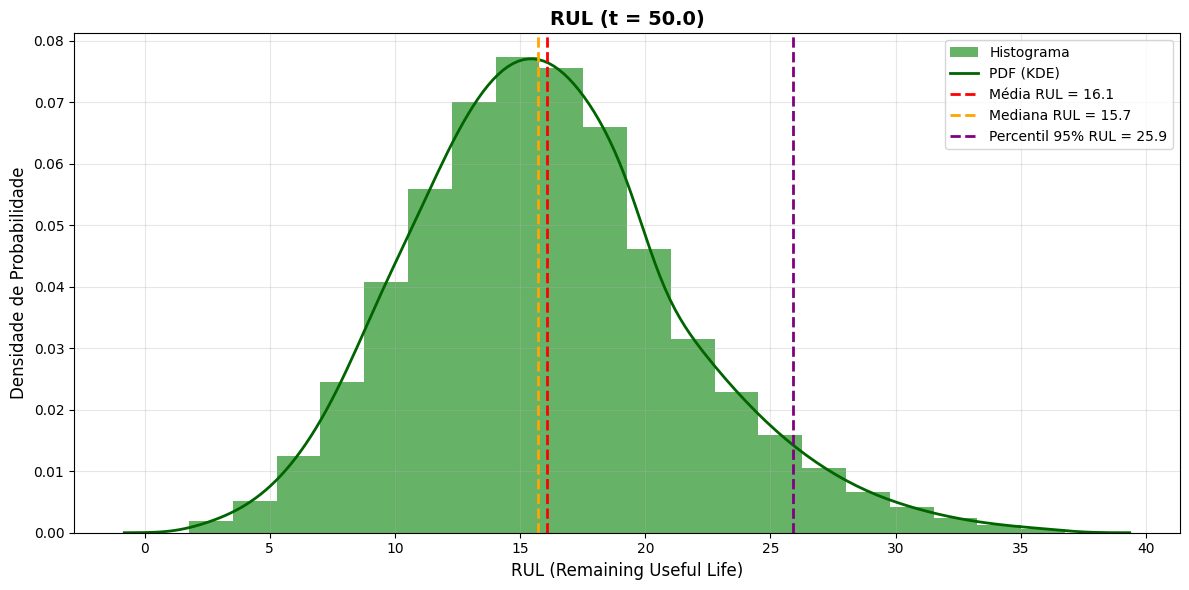


Estatísticas do RUL condicional para t = 50.0:
Média RUL: 16.06
Mediana RUL: 15.72
Desvio padrão RUL: 5.43
Percentil 95% RUL: 25.88
Min RUL: 1.77
Max RUL: 36.77


In [12]:
# Para um tempo específico, mostrar a PDF do RUL

tempo_especifico = 50.0  # Tempo em que queremos avaliar o RUL
print(f"\nAnalisando RUL condicional para t = {tempo_especifico}")

# Encontrar o índice mais próximo do tempo especificado
idx_tempo = np.argmin(np.abs(np.array(lista_tempos) - tempo_especifico))
tempo_especifico_real = lista_tempos[idx_tempo]

# Pegar as amostras para este tempo
amostras_no_tempo = amostras_por_tempo[idx_tempo]

# Calcular RUL condicional (considerando que sobreviveu até este tempo)
# Aqui assumimos que RUL = tempo_de_falha - tempo_atual
# Vamos calcular o RUL para cada amostra que ainda está viva

ruls_condicionais = []
for i in range(n_amostras):
    # Verificar se a amostra sobreviveu até o tempo atual (valor > threshold)
    if amostras_no_tempo[i] > threshold:
        # Encontrar o tempo de falha para esta amostra
        amostras_individuais = [amostras_por_tempo[t][i] for t in range(len(lista_tempos))]
        
        tempo_falha = None
        for t in range(idx_tempo + 1, len(lista_tempos)):
            if amostras_individuais[t] <= threshold and amostras_individuais[t-1] > threshold:
                t_anterior = lista_tempos[t-1]
                t_atual = lista_tempos[t]
                val_anterior = amostras_individuais[t-1]
                val_atual = amostras_individuais[t]
                
                fracao = (threshold - val_anterior) / (val_atual - val_anterior)
                tempo_falha = t_anterior + fracao * (t_atual - t_anterior)
                break
        
        if tempo_falha is not None:
            rul = tempo_falha - tempo_especifico_real
            if rul > 0:
                ruls_condicionais.append(rul)

# Plotar PDF do RUL condicional
if ruls_condicionais:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ruls_condicionais = np.array(ruls_condicionais)
    ax.hist(ruls_condicionais, bins=20, density=True, alpha=0.6, color='green', label='Histograma')
    sns.kdeplot(ruls_condicionais, ax=ax, color='darkgreen', linewidth=2, label='PDF (KDE)')
    
    # Estatísticas
    media_rul = np.mean(ruls_condicionais)
    mediana_rul = np.median(ruls_condicionais)
    percentil_95_rul = np.percentile(ruls_condicionais, 95)
    
    ax.axvline(media_rul, color='red', linestyle='--', linewidth=2, label=f'Média RUL = {media_rul:.1f}')
    ax.axvline(mediana_rul, color='orange', linestyle='--', linewidth=2, label=f'Mediana RUL = {mediana_rul:.1f}')
    ax.axvline(percentil_95_rul, color='purple', linestyle='--', linewidth=2, label=f'Percentil 95% RUL = {percentil_95_rul:.1f}')
    
    ax.set_xlabel('RUL (Remaining Useful Life)', fontsize=12)
    ax.set_ylabel('Densidade de Probabilidade', fontsize=12)
    ax.set_title(f'RUL (t = {tempo_especifico_real:.1f})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstatísticas do RUL condicional para t = {tempo_especifico_real:.1f}:")
    print(f"Média RUL: {media_rul:.2f}")
    print(f"Mediana RUL: {mediana_rul:.2f}")
    print(f"Desvio padrão RUL: {np.std(ruls_condicionais):.2f}")
    print(f"Percentil 95% RUL: {percentil_95_rul:.2f}")
    print(f"Min RUL: {np.min(ruls_condicionais):.2f}")
    print(f"Max RUL: {np.max(ruls_condicionais):.2f}")
else:
    print(f"Nenhuma amostra sobreviveu até o tempo {tempo_especifico_real:.1f}")